# Minimum Thrust Rendezvous using Clohessy-Wiltshire (CW) Equations
 
CW 방정식 기반 3차원 랑데부 최소 추력 최적화

---
## 1. Problem Description

Deputy 위성이 Chief 위성에 랑데부하는 문제를 푼다.

두 위성의 초기 상태는 ECI (Earth-Centered Inertial)=좌표계로 주어진다.  
이를 RTN (Hill) 프레임의 상대 상태로 변환한 뒤, 최소 추력 궤적을 계산한다.

상태벡터는 RTN 프레임에서 다음과 같이 정의한다:

$$x = \begin{bmatrix} x \\ y \\ z \\ \dot{x} \\ \dot{y} \\ \dot{z} \end{bmatrix} \in \mathbb{R}^6$$

- $(x,\ y,\ z)$: Deputy의 Chief에 대한 상대 위치 [m]
- $(\dot{x},\ \dot{y},\ \dot{z})$: 상대 속도 [m/s]
- $x$ 축: R (Radial), $y$ 축: T (Transverse), $z$ 축: N (Normal)

**목표:** 최종 시각 $t=N$에 Deputy가 Chief에 도달 ($x_N = x_{\text{des}}$) 하면서 총 추력 에너지를 최소화:

$$\begin{aligned}
\min_{u} \quad & \sum_{t=0}^{N-1} \|u_t\|^2 \\
\text{subject to} \quad & x_{t+1} = A x_t + B u_t, \quad t = 0, \ldots, N-1 \\
& x_N = x_{\text{des}}
\end{aligned}$$

---
## 2. ECI to RTN Coordinate Transformation

### 2.1 RTN 기저벡터 정의

Chief의 ECI 위치/속도 벡터 $\vec{r}_c,\ \vec{v}_c$ 로부터 RTN 기저벡터를 구성한다:

$$\hat{r} = \frac{\vec{r}_c}{|\vec{r}_c|}, \qquad \hat{n} = \frac{\vec{r}_c \times \vec{v}_c}{|\vec{r}_c \times \vec{v}_c|}, \qquad \hat{t} = \hat{n} \times \hat{r}$$

### 2.2 ECI → RTN 회전행렬

$$C = \begin{bmatrix} \hat{r}^\top \\ \hat{t}^\top \\ \hat{n}^\top \end{bmatrix} \in \mathbb{R}^{3 \times 3}$$

### 2.3 상대 위치 변환

$$\delta\vec{r}_{\text{ECI}} = \vec{r}_d - \vec{r}_c, \qquad \delta\vec{r}_{\text{RTN}} = C\, \delta\vec{r}_{\text{ECI}}$$

### 2.4 상대 속도 변환 (비관성 보정 포함)

RTN 프레임은 회전하는 비관성 좌표계이므로, 속도 변환 시 반드시 보정항이 필요하다:

$$\vec{V}_{\text{RTN}} = \vec{V}_{\text{ECI}} - \vec{\omega}_{H/I} \times \vec{r}$$

여기서 $\vec{\omega}_{H/I}$는 RTN 프레임의 관성계에 대한 각속도:

$$\vec{\omega}_{H/I} = \frac{\vec{r}_c \times \vec{v}_c}{|\vec{r}_c|^2}$$

따라서 상대 속도의 RTN 성분:

$$\delta\vec{v}_{\text{ECI}} = \vec{v}_d - \vec{v}_c, \qquad \delta\vec{v}_{\text{RTN}} = C\,\bigl(\delta\vec{v}_{\text{ECI}} - \vec{\omega}_{H/I} \times \delta\vec{r}_{\text{ECI}}\bigr)$$

### 2.5 초기 상태벡터

$$x_0 = \begin{bmatrix} \delta\vec{r}_{\text{RTN}} \\ \delta\vec{v}_{\text{RTN}} \end{bmatrix} \in \mathbb{R}^6$$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import scipy.sparse.linalg as sla

# 지구 상수
mu  = 3.986004418e14   # 지구 중력 상수 [m^3/s^2]
R_E = 6371e3           # 지구 반지름 [m]
# ECI 초기 조건 입력
# 단위: 위치 [m], 속도 [m/s]

# Chief (기준 위성) ECI 상태
r_c = np.array([6871e3,    0.0,      0.0  ])   # 위치 [m]
v_c = np.array([0.0,    7612.6,      0.0  ])   # 속도 [m/s]  (원궤도 속도)

# Deputy (추적 위성) ECI 상태
r_d = np.array([6871e3 - 500.0,  -1000.0,   200.0])   # 위치 [m]
v_d = np.array([0.5,              7612.3,     0.1 ])   # 속도 [m/s]

# 궤도 파라미터
a     = np.linalg.norm(r_c)       # 장반경 (원궤도 가정) [m]
n     = np.sqrt(mu / a**3)        # mean motion [rad/s]
T_orb = 2 * np.pi / n             # 궤도 주기 [s]

print(f'Chief 궤도 반경  a = {a/1e3:.1f} km')
print(f'Mean motion      n = {n:.6f} rad/s')
print(f'궤도 주기        T = {T_orb/60:.2f} min')

Chief 궤도 반경  a = 6871.0 km
Mean motion      n = 0.001109 rad/s
궤도 주기        T = 94.47 min


In [30]:
r_hat = r_c/np.linalg.norm(r_c)
h_vec = np.cross(r_c, v_c)
n_hat = h_vec/np.linalg.norm(h_vec)
t_hat = np.cross(n_hat, r_hat)

w = h_vec/np.linalg.norm(r_c)**2


C = np.array([r_hat,
              t_hat, 
              n_hat])

r_rel_ECI = r_d - r_c
r_rel_RTN = C@r_rel_ECI
v_rel_ECI = v_d -  v_c
v_rel_RTN = C@(v_rel_ECI - np.cross(w, r_rel_ECI))

x0 =np.concatenate([r_rel_RTN, v_rel_RTN])
x_des = np.zeros(6)

print('초기 상대 상태 (RTN 프레임):')
print(f'  위치 [R, T, N]            : {r_rel_RTN}  m')
print(f'  속도 [Rdot, Tdot, Ndot]   : {v_rel_RTN}  m/s')
print(f'  초기 거리                 : {np.linalg.norm(r_rel_RTN):.2f} m')

초기 상대 상태 (RTN 프레임):
  위치 [R, T, N]            : [ -500. -1000.   200.]  m
  속도 [Rdot, Tdot, Ndot]   : [-0.60793189  0.25396594  0.1       ]  m/s
  초기 거리                 : 1135.78 m


---
## 3. Clohessy-Wiltshire (CW) Equations

Chief가 원궤도를 돌고 있다고 가정하면, RTN 프레임에서 Deputy의 상대 운동은 CW 방정식으로 기술된다:

$$\ddot{x} = 3n^2 x + 2n\dot{y} + u_x$$
$$\ddot{y} = -2n\dot{x} + u_y$$
$$\ddot{z} = -n^2 z + u_z$$

여기서 $n = \sqrt{\mu/a^3}$ 은 Chief 원궤도의 평균 각속도 (mean motion)이다.

연속시간 상태방정식으로 쓰면 $\dot{x} = A_c x + B_c u$, 여기서:

$$A_c = \begin{bmatrix}
0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 \\
3n^2 & 0 & 0 & 0 & 2n & 0 \\
0 & 0 & 0 & -2n & 0 & 0 \\
0 & 0 & -n^2 & 0 & 0 & 0
\end{bmatrix}, \qquad
B_c = \begin{bmatrix}
0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \\
1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1
\end{bmatrix}$$

In [31]:
Ac = np.zeros((6,6))
Bc = np.zeros((6,3))

Ac[0, 3] = 1.0;   Ac[1, 4] = 1.0;   Ac[2, 5] = 1.0
Ac[3, 0] =  3*n**2;   Ac[3, 4] =  2*n
Ac[4, 3] = -2*n
Ac[5, 2] = -n**2
Bc[3,0] = Bc[4,1] = Bc[5,2] = 1.0

print('Ac (6x6):')
print(np.array2string(Ac, formatter={'float_kind': lambda x: f'{x:9.4f}'}))
print('\nBc (6x3):')
print(Bc)

Ac (6x6):
[[   0.0000    0.0000    0.0000    1.0000    0.0000    0.0000]
 [   0.0000    0.0000    0.0000    0.0000    1.0000    0.0000]
 [   0.0000    0.0000    0.0000    0.0000    0.0000    1.0000]
 [   0.0000    0.0000    0.0000    0.0000    0.0022    0.0000]
 [   0.0000    0.0000    0.0000   -0.0022    0.0000    0.0000]
 [   0.0000    0.0000   -0.0000    0.0000    0.0000    0.0000]]

Bc (6x3):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


---
## 4. Discretization (Zero-Order Hold)

샘플링 간격 $\Delta t$ 동안 $u$가 상수라 가정하면 (ZOH):

$$x_{t+1} = A x_t + B u_t$$

이산화 행렬은 행렬 지수함수로 구한다. $B$를 동시에 구하기 위해 확장 행렬을 한 번에 지수화한다:

$$\exp\!\left(\begin{bmatrix} A_c & B_c \\ 0 & 0 \end{bmatrix} \Delta t\right) = \begin{bmatrix} A & B \\ 0 & I \end{bmatrix}$$

좌상단 블록 = $A$, 우상단 블록 = $B$

In [32]:
N     = 500
t_f   = 1.0 * T_orb
dt    = t_f / N
ts    = np.linspace(0, t_f, N+1)

print(f'기동 시간 : {t_f/60:.1f} min  ({t_f/T_orb:.1f} 궤도 주기)')
print(f'시간 간격 : {dt:.2f} s,   스텝 수 : {N}')

기동 시간 : 94.5 min  (1.0 궤도 주기)
시간 간격 : 11.34 s,   스텝 수 : 500


In [33]:
n_1 = Ac.shape[1]
m = Bc.shape[1]

M = np.zeros((n_1+m, n_1+m))

M[:n_1, :n_1] = Ac
M[:n_1, n_1:] = Bc

eM = expm(M*dt)

A = eM[:n_1, :n_1]
B = eM[:n_1, n_1:]

print('\nDiscrete A (6x6):')
print(np.array2string(A, formatter={'float_kind': lambda x: f'{x:9.5f}'}))
print('\nDiscrete B (6x3):')
print(np.array2string(B, formatter={'float_kind': lambda x: f'{x:9.5f}'}))



Discrete A (6x6):
[[  1.00024   0.00000   0.00000  11.33599   0.14245   0.00000]
 [ -0.00000   1.00000   0.00000  -0.14245  11.33510   0.00000]
 [  0.00000   0.00000   0.99992   0.00000   0.00000  11.33599]
 [  0.00004  -0.00000  -0.00000   0.99992   0.02513  -0.00000]
 [ -0.00000   0.00000   0.00000  -0.02513   0.99968   0.00000]
 [  0.00000   0.00000  -0.00001   0.00000   0.00000   0.99992]]

Discrete B (6x3):
[[ 64.25488   0.53830   0.00000]
 [ -0.53830  64.25234   0.00000]
 [  0.00000   0.00000  64.25488]
 [ 11.33599   0.14245  -0.00000]
 [ -0.14245  11.33510   0.00000]
 [  0.00000   0.00000  11.33599]]


---
## 5. Minimum Thrust as Least-Norm Problem

이산 동역학을 $t=0$부터 재귀적으로 전개하면:

$$x_1 = Ax_0 + Bu_0$$
$$x_2 = A^2x_0 + ABu_0 + Bu_1$$
$$\vdots$$
$$x_N = A^N x_0 + \underbrace{\begin{bmatrix} A^{N-1}B & A^{N-2}B & \cdots & AB & B \end{bmatrix}}_{G\,\in\,\mathbb{R}^{6\times 3N}} \begin{bmatrix} u_0 \\ u_1 \\ \vdots \\ u_{N-1} \end{bmatrix}$$

즉 $x_N = A^N x_0 + G\mathbf{u}$ 이다. 랑데부 조건 $x_N = x_{\text{des}}$를 대입하면:

$$G\mathbf{u} = \underbrace{x_{\text{des}} - A^N x_0}_{b}$$

동역학 제약이 $G$ 안에 흡수되므로, 원래 문제는 **Least-Norm 문제**로 환원된다:

$$\min_{\mathbf{u}} \|\mathbf{u}\|^2 \quad \\\text{subject to} \quad G\mathbf{u} = b$$

해석적 최적해 (Minimum-Norm Pseudoinverse):

$$\mathbf{u}^* = G^\top (G G^\top)^{-1} b$$

해가 존재할 조건: $\text{rank}(G) = 6$ → CW 시스템의 **가제어성 (Controllability)** 조건

In [34]:
G = np.zeros((6, 3*N))

for i in range(N) :
    G[:, 3*i:3*(i+1)] = np.linalg.matrix_power(A, N-i-1)@B

rank_G = np.linalg.matrix_rank(G)
print(f'G shape  : {G.shape}')
print(f'rank(G)  : {rank_G}   (가제어 조건: rank = 6)')
print(f'가제어성 : {"OK" if rank_G == 6 else "FAIL"}')

AN = np.linalg.matrix_power(A,N)
b = x_des - AN@x0

u_hat, *_ = sla.lsqr(G,b)

u_opt = u_hat.reshape(N,3)
u_opt_ln = u_opt.copy()   # Least-Norm 해 보존
print(f'총 추력 에너지  ||u||^2 = {np.sum(u_opt**2):.6f}  (m/s^2)^2')
print(f'최대 추력 크기          = {np.max(np.linalg.norm(u_opt, axis=1)):.6f}  m/s^2')


G shape  : (6, 1500)
rank(G)  : 6   (가제어 조건: rank = 6)
가제어성 : OK
총 추력 에너지  ||u||^2 = 0.000099  (m/s^2)^2
최대 추력 크기          = 0.001221  m/s^2


---
## 6. Forward Simulation

$$x_{t+1} = A x_t + B u_t^*, \quad t = 0, 1, \ldots, N-1$$

In [35]:
x_traj = np.zeros((6, N+1))
x_traj[:,0] = x0

for t in range(N) :
    x_traj[: ,t+1] = A@(x_traj[:,t]) + B@(u_opt[t, :])

x_traj_ln = x_traj.copy()   # Least-Norm 궤적 보존
x_final = x_traj[:, -1]

print('터미널 상태 검증:')
print(f'  위치 오차  : {np.linalg.norm(x_final[:3]):.4e}  m')
print(f'  속도 오차  : {np.linalg.norm(x_final[3:]):.4e}  m/s')
print(f'  총 delta-V : {np.sum(np.linalg.norm(u_opt, axis=1)) * dt:.4f}  m/s')


터미널 상태 검증:
  위치 오차  : 3.8074e-06  m
  속도 오차  : 7.7097e-09  m/s
  총 delta-V : 2.0098  m/s


---
## 7. Results: State History

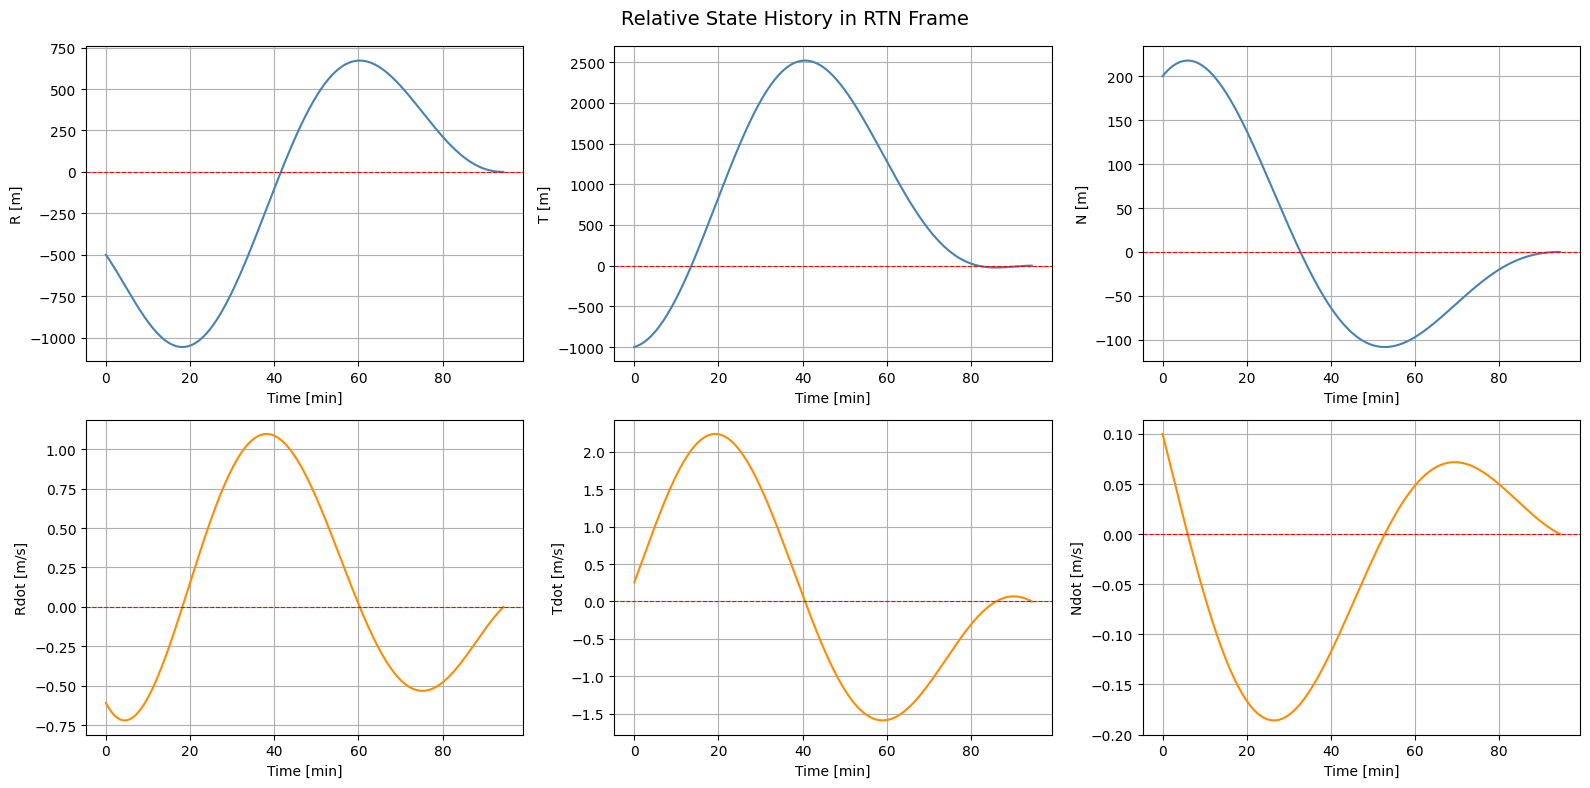

In [36]:
ts_min = ts / 60
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Relative State History in RTN Frame', fontsize=14)

pos_labels = ['R [m]', 'T [m]', 'N [m]']
vel_labels  = ['Rdot [m/s]', 'Tdot [m/s]', 'Ndot [m/s]']

for i in range(3):
    axes[0,i].plot(ts_min, x_traj[i,:], color='steelblue')
    axes[0,i].set_ylabel(pos_labels[i]);  axes[0,i].set_xlabel('Time [min]')
    axes[0,i].axhline(0, color='r', linestyle='--', lw=0.8);  axes[0,i].grid(True)

    axes[1,i].plot(ts_min, x_traj[i+3,:], color='darkorange')
    axes[1,i].set_ylabel(vel_labels[i]);  axes[1,i].set_xlabel('Time [min]')
    axes[1,i].axhline(0, color='r', linestyle='--', lw=0.8);  axes[1,i].grid(True)

plt.tight_layout()
plt.show()

---
## 8. Results: Thrust History

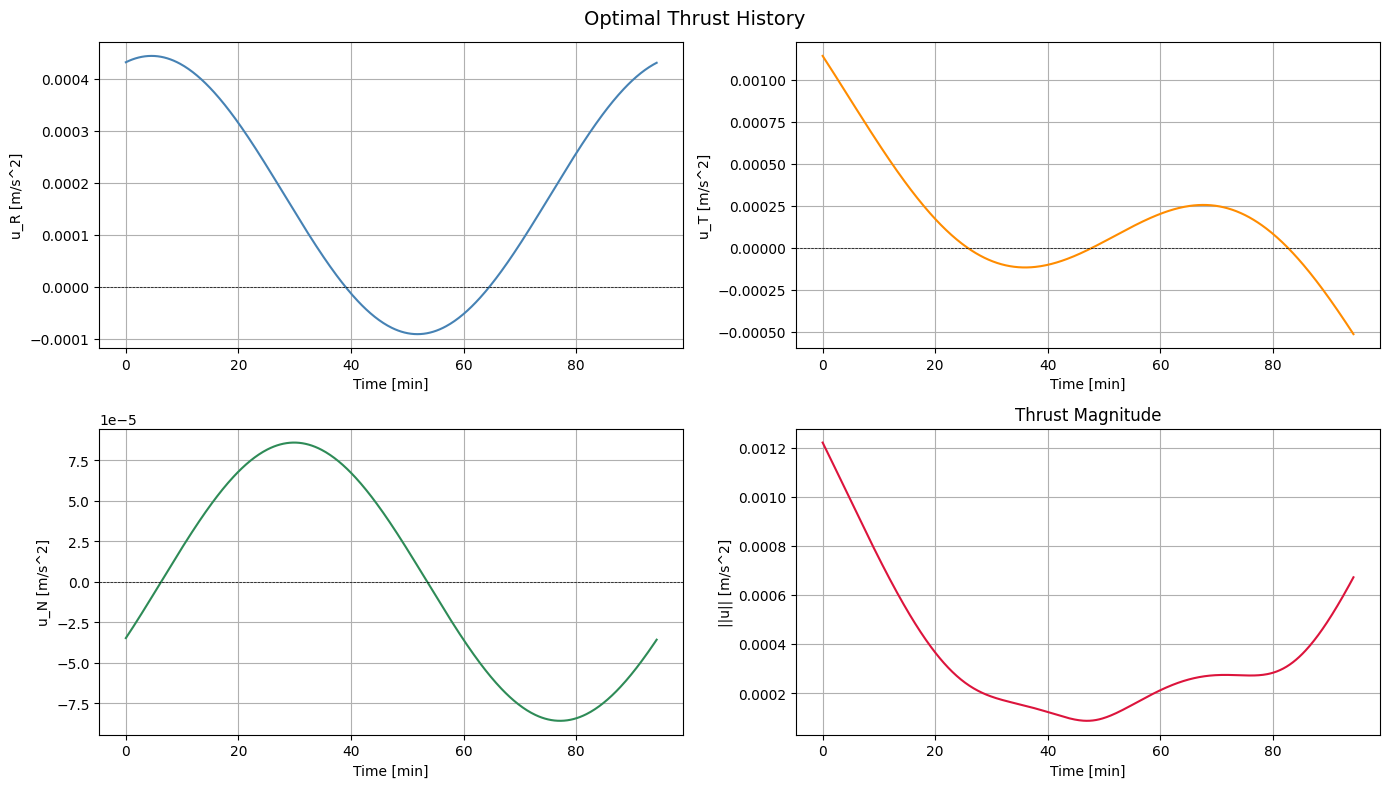

Total delta-V = 2.0098 m/s


In [37]:
ts_ctrl    = ts[:-1] / 60
thrust_mag = np.linalg.norm(u_opt, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Optimal Thrust History', fontsize=14)

for i, (label, color) in enumerate(zip(['u_R [m/s^2]','u_T [m/s^2]','u_N [m/s^2]'],
                                        ['steelblue','darkorange','seagreen'])):
    ax = [axes[0,0], axes[0,1], axes[1,0]][i]
    ax.plot(ts_ctrl, u_opt[:, i], color=color)
    ax.set_ylabel(label);  ax.set_xlabel('Time [min]')
    ax.axhline(0, color='k', linestyle='--', lw=0.5);  ax.grid(True)

axes[1,1].plot(ts_ctrl, thrust_mag, color='crimson')
axes[1,1].set_ylabel('||u|| [m/s^2]');  axes[1,1].set_xlabel('Time [min]')
axes[1,1].set_title('Thrust Magnitude');  axes[1,1].grid(True)

plt.tight_layout()
plt.show()
print(f'Total delta-V = {np.sum(thrust_mag)*dt:.4f} m/s')

---
## 9. Results: 3D Trajectory in RTN Frame

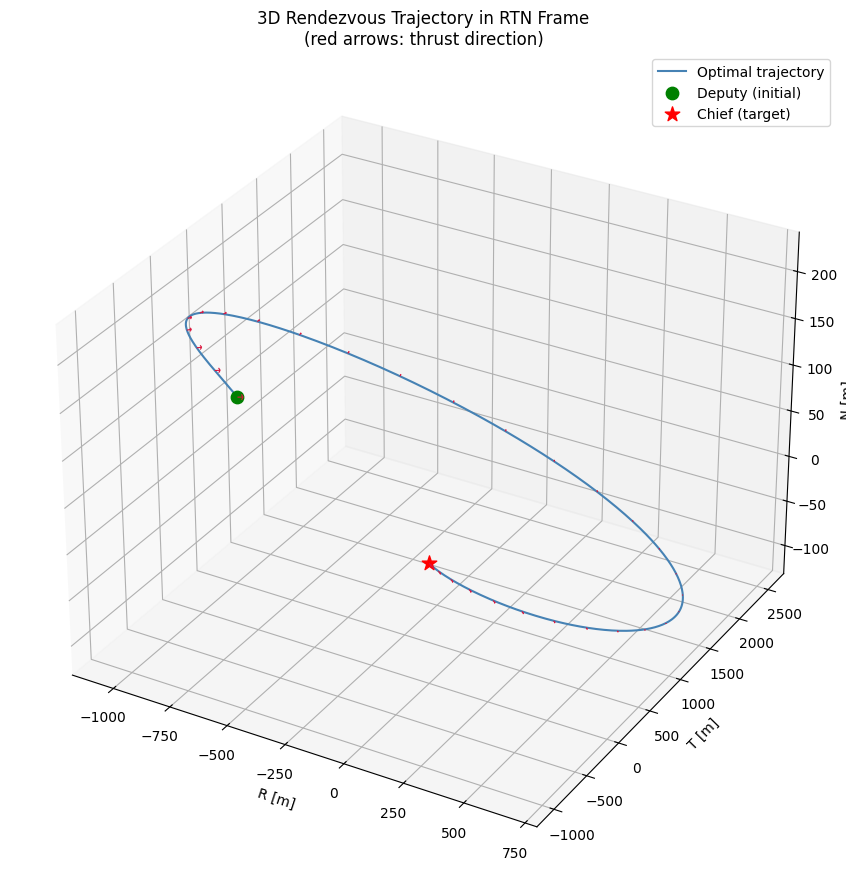

In [38]:
fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(x_traj[0,:], x_traj[1,:], x_traj[2,:],
        color='steelblue', lw=1.5, label='Optimal trajectory')
ax.scatter(*x0[:3], color='green', s=80,  zorder=5, label='Deputy (initial)')
ax.scatter(0, 0, 0,  color='red',   s=120, marker='*', zorder=5, label='Chief (target)')

skip = N // 30;  scale = 3e4
for i in range(0, N, skip):
    ax.quiver(x_traj[0,i], x_traj[1,i], x_traj[2,i],
              u_opt[i,0]*scale, u_opt[i,1]*scale, u_opt[i,2]*scale,
              color='crimson', lw=0.8, arrow_length_ratio=0.3)

ax.set_xlabel('R [m]');  ax.set_ylabel('T [m]');  ax.set_zlabel('N [m]')
ax.set_title('3D Rendezvous Trajectory in RTN Frame\n(red arrows: thrust direction)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Summary

전체 흐름:

$$\underbrace{(\vec{r}_c,\vec{v}_c,\vec{r}_d,\vec{v}_d)}_{\text{ECI 입력}}
\xrightarrow{C,\;\vec{\omega}}
\underbrace{x_0}_{\text{RTN 초기 상태}}
\xrightarrow{A_c,B_c \to A,B}
\underbrace{G}_{6\times 3N}
\xrightarrow{\min\|\mathbf{u}\|^2}
\underbrace{\mathbf{u}^*}_{\text{최적 추력}}
\xrightarrow{x_{t+1}=Ax_t+Bu_t}
\text{랑데부 궤적}$$

**주의사항:** 유한 추력이라고 고려하여 추력의 상한선을 추가하여 QP문제로 정의하고 해결한다.

---
## 11. $u_{\max}$ 제한 후 QP로 확장

Least-Norm 해는 추력 상한이 없어 일부 구간에서 추력이 매우 커질 수 있다.  
추력 상한 $u_{\max}$ 를 부등식 제약으로 추가하면 문제는 **QP (Quadratic Programming)** 로 확장된다:

$$\begin{aligned}
\min_{u} \quad & \sum_{t=0}^{N-1} \|u_t\|^2 \\
\text{subject to} \quad & x_{t+1} = A x_t + B u_t \\
& x_N = x_{\text{des}} \\
& \|u_t\|_2 \leq u_{\max}, \quad t = 0, \ldots, N-1
\end{aligned}$$

등식 제약 $G\mathbf{u}=b$ 는 Least-Norm과 동일하고, 부등식 제약만 추가된다.  
볼록 QP ($P=I \succ 0$) 이므로 CVXPY + SCS solver로 전역 최솟값이 보장된다.

In [46]:
import cvxpy as cp

# 무제약 최대 추력 확인
max_thrust_free = np.max(np.linalg.norm(u_opt_ln, axis=1))
print(f'Least-Norm 최대 추력 : {max_thrust_free:.6f} m/s²')

# u_max를 그보다 작게 설정 → 제약 활성화
u_max = max_thrust_free * 0.6
print(f'설정한 u_max         : {u_max:.6f} m/s²  (LN 최대의 70%)')


Least-Norm 최대 추력 : 0.001221 m/s²
설정한 u_max         : 0.000733 m/s²  (LN 최대의 70%)


In [47]:
# ── QP 풀기 ──────────────────────────────────────────────
u_var = cp.Variable((N, 3))
u_vec = cp.reshape(u_var, (3*N,), order='C')

objective    = cp.Minimize(cp.sum_squares(u_var))
constraints  = [G @ u_vec == b]                        # 랑데부 등식 제약
constraints += [cp.norm(u_var[t], 2) <= u_max          # 각 스텝 추력 상한
                for t in range(N)]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS, verbose=False)

print(f'Solver 상태     : {prob.status}')
assert prob.status == 'optimal', 'QP infeasible — u_max를 키워주세요'

u_opt_qp = u_var.value   # (N, 3)
print(f'총 추력 에너지  : {np.sum(u_opt_qp**2):.6f}  (m/s²)²')
print(f'최대 추력 크기  : {np.max(np.linalg.norm(u_opt_qp, axis=1)):.6f}  m/s²')
print(f'u_max 준수 여부 : {np.max(np.linalg.norm(u_opt_qp, axis=1)) <= u_max + 1e-4}')

# ── QP Forward Simulation ─────────────────────────────────
x_traj_qp = np.zeros((6, N+1))
x_traj_qp[:, 0] = x0
for t in range(N):
    x_traj_qp[:, t+1] = A @ x_traj_qp[:, t] + B @ u_opt_qp[t]

x_final_qp = x_traj_qp[:, -1]
print(f'\nQP 터미널 검증:')
print(f'  위치 오차  : {np.linalg.norm(x_final_qp[:3]):.4e}  m')
print(f'  속도 오차  : {np.linalg.norm(x_final_qp[3:]):.4e}  m/s')
print(f'  총 delta-V : {np.sum(np.linalg.norm(u_opt_qp, axis=1)) * dt:.4f}  m/s')


Solver 상태     : optimal
총 추력 에너지  : 0.000101  (m/s²)²
최대 추력 크기  : 0.000984  m/s²
u_max 준수 여부 : False

QP 터미널 검증:
  위치 오차  : 4.0570e-04  m
  속도 오차  : 1.3758e-07  m/s
  총 delta-V : 2.1310  m/s


---
## 12. Least-Norm vs QP 비교


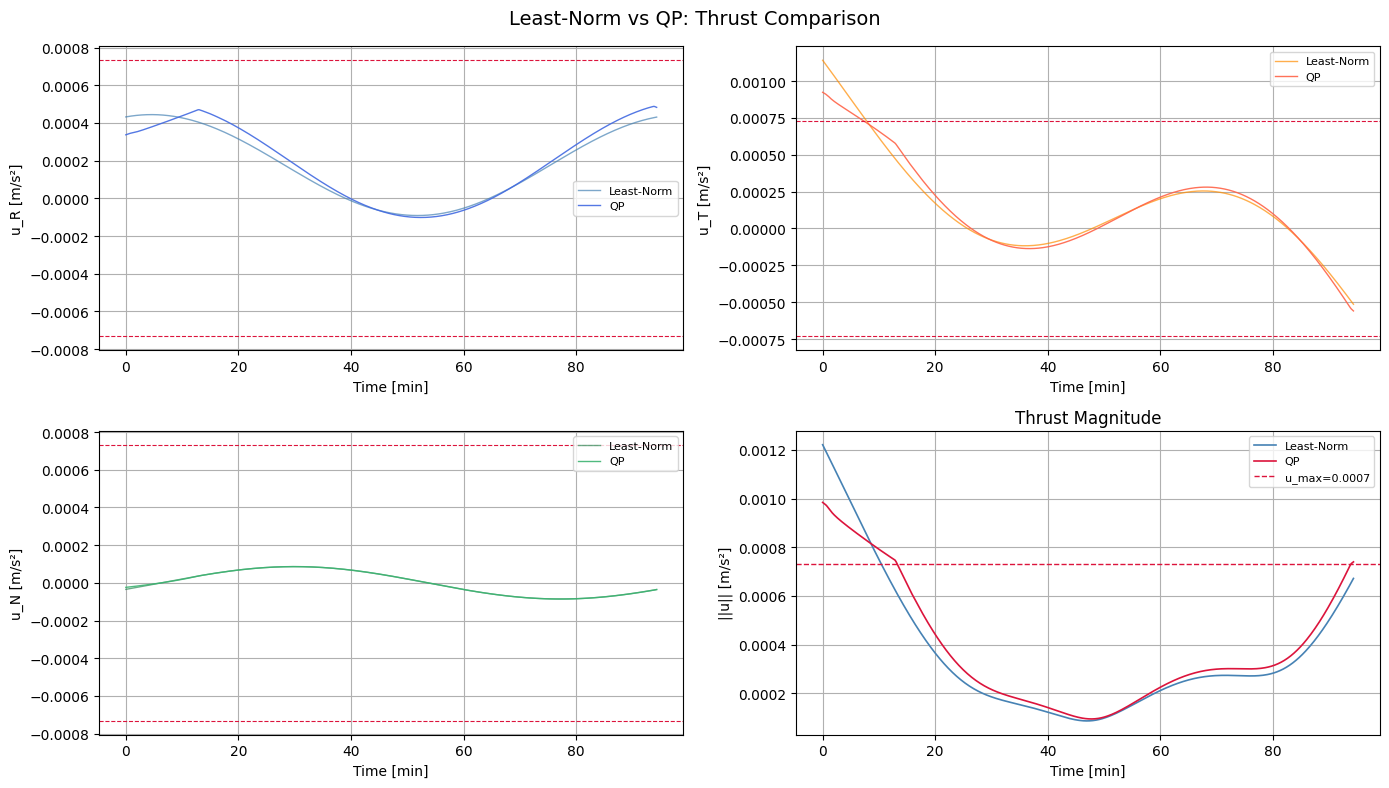

LN  총 delta-V : 2.0098 m/s
QP  총 delta-V : 2.1310 m/s


In [48]:
ts_ctrl = ts[:-1] / 60
mag_ln = np.linalg.norm(u_opt_ln, axis=1)
mag_qp = np.linalg.norm(u_opt_qp, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Least-Norm vs QP: Thrust Comparison', fontsize=14)

labels = ['u_R [m/s²]', 'u_T [m/s²]', 'u_N [m/s²]']
colors_ln = ['steelblue', 'darkorange', 'seagreen']
colors_qp = ['royalblue', 'tomato',     'mediumseagreen']

for i in range(3):
    ax = [axes[0,0], axes[0,1], axes[1,0]][i]
    ax.plot(ts_ctrl, u_opt_ln[:, i], color=colors_ln[i], lw=1.0, alpha=0.7, label='Least-Norm')
    ax.plot(ts_ctrl, u_opt_qp[:, i], color=colors_qp[i], lw=1.0, alpha=0.9, label='QP')
    ax.axhline( u_max, color='crimson', ls='--', lw=0.8)
    ax.axhline(-u_max, color='crimson', ls='--', lw=0.8)
    ax.set_ylabel(labels[i]); ax.set_xlabel('Time [min]')
    ax.legend(fontsize=8); ax.grid(True)

axes[1,1].plot(ts_ctrl, mag_ln, color='steelblue', lw=1.2, label='Least-Norm')
axes[1,1].plot(ts_ctrl, mag_qp, color='crimson',   lw=1.2, label='QP')
axes[1,1].axhline(u_max, color='crimson', ls='--', lw=1.0, label=f'u_max={u_max:.4f}')
axes[1,1].set_ylabel('||u|| [m/s²]'); axes[1,1].set_xlabel('Time [min]')
axes[1,1].set_title('Thrust Magnitude'); axes[1,1].legend(fontsize=8); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f'LN  총 delta-V : {np.sum(mag_ln)*dt:.4f} m/s')
print(f'QP  총 delta-V : {np.sum(mag_qp)*dt:.4f} m/s')


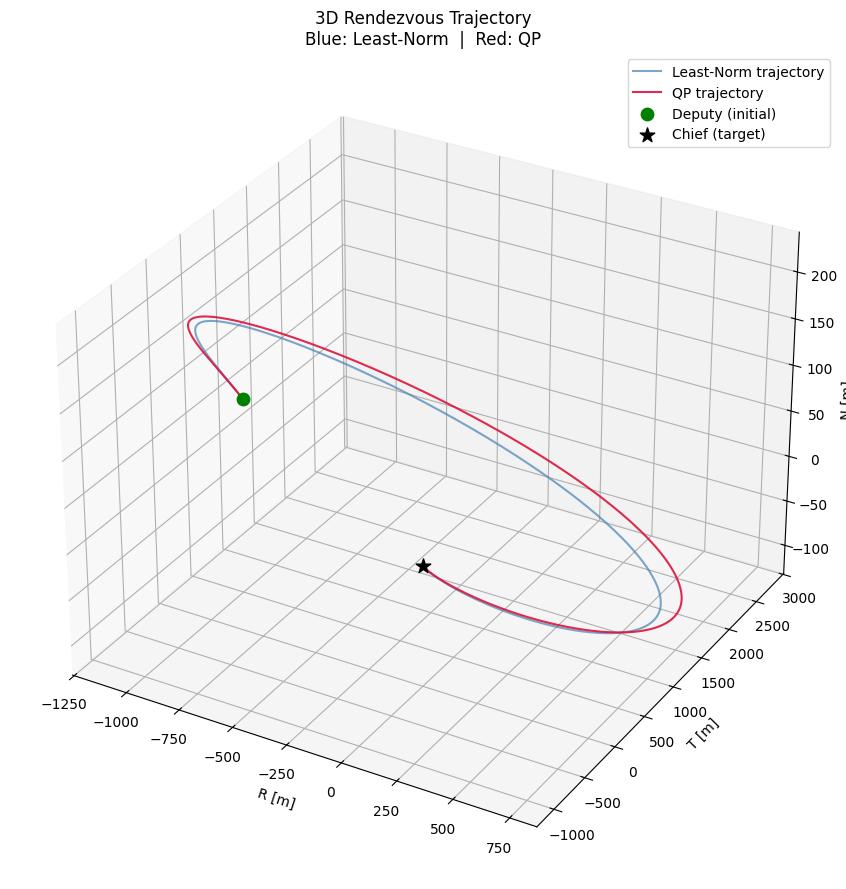

In [49]:
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(x_traj_ln[0,:], x_traj_ln[1,:], x_traj_ln[2,:],
        color='steelblue', lw=1.5, label='Least-Norm trajectory', alpha=0.7)
ax.plot(x_traj_qp[0,:], x_traj_qp[1,:], x_traj_qp[2,:],
        color='crimson',   lw=1.5, label='QP trajectory',         alpha=0.9)

ax.scatter(*x0[:3],  color='green', s=80,  zorder=5, label='Deputy (initial)')
ax.scatter(0, 0, 0,  color='black', s=120, marker='*', zorder=5, label='Chief (target)')

ax.set_xlabel('R [m]'); ax.set_ylabel('T [m]'); ax.set_zlabel('N [m]')
ax.set_title('3D Rendezvous Trajectory\nBlue: Least-Norm  |  Red: QP')
ax.legend()
plt.tight_layout()
plt.show()
